<a href="https://colab.research.google.com/github/ayu69hub/machine-learning/blob/main/ML_algorithms.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 1. Linear Regression Algo.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_california_housing

In [2]:
df = fetch_california_housing()

In [3]:
dataset = pd.DataFrame(df.data)

In [4]:
dataset

,0,1,2,3,4,5,6,7
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25
...,...,...,...,...,...,...,...,...
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48,-121.09
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49,-121.21
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,-121.22
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,-121.32


In [5]:
dataset.columns = df.feature_names

In [6]:
dataset.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25


In [7]:
#independent features and dependent features
X=dataset
y=df.target

In [8]:
y

array([4.526, 3.585, 3.521, ..., 0.923, 0.847, 0.894])

In [9]:
#train test splits
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.3,random_state=42)


In [10]:
X_train

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
7061,4.1312,35.0,5.882353,0.975490,1218.0,2.985294,33.93,-118.02
14689,2.8631,20.0,4.401210,1.076613,999.0,2.014113,32.79,-117.09
17323,4.2026,24.0,5.617544,0.989474,731.0,2.564912,34.59,-120.14
10056,3.1094,14.0,5.869565,1.094203,302.0,2.188406,39.26,-121.00
15750,3.3068,52.0,4.801205,1.066265,1526.0,2.298193,37.77,-122.45
...,...,...,...,...,...,...,...,...
11284,6.3700,35.0,6.129032,0.926267,658.0,3.032258,33.78,-117.96
11964,3.0500,33.0,6.868597,1.269488,1753.0,3.904232,34.02,-117.43
5390,2.9344,36.0,3.986717,1.079696,1756.0,3.332068,34.03,-118.38
860,5.7192,15.0,6.395349,1.067979,1777.0,3.178891,37.58,-121.96


In [11]:
#standarddizing the dataset
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()


In [12]:
X_train=scaler.fit_transform(X_train)

In [13]:
X_test=scaler.transform(X_test)

In [14]:
from sklearn.linear_model import LinearRegression
# cross validation
from sklearn.model_selection import cross_val_score

In [15]:
regression=LinearRegression()
regression.fit(X_train,y_train)

LinearRegression()

In [16]:
mse= cross_val_score(regression,X_train,y_train,scoring='neg_mean_squared_error',cv=10)

In [17]:
np.mean(mse)

np.float64(-0.5257104326777)

In [18]:
#prediction
reg_pred=regression.predict(X_test)


In [19]:
reg_pred

array([0.72604907, 1.76743383, 2.71092161, ..., 2.07465531, 1.57371395,
       1.82744133])

/tmp/ipykernel_7083/1457231473.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(reg_pred-y_test)


<Axes: ylabel='Density'>

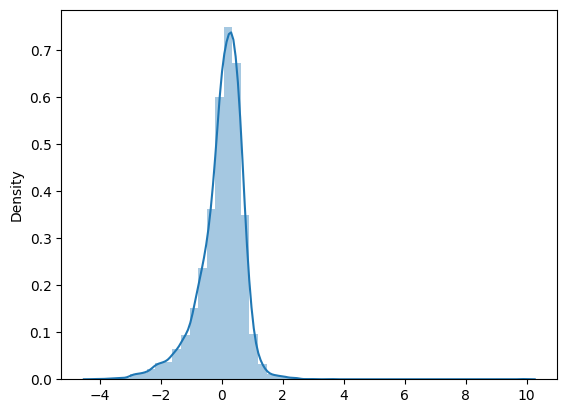

In [20]:
sns.distplot(reg_pred-y_test)

In [21]:
from sklearn.metrics import r2_score


In [22]:
score=r2_score(reg_pred,y_test)

In [23]:
score

0.3451339380943961

# 2. Ridge Regression Algo.
(overfitting solve krne ke liye use hota h)

In [24]:
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV

In [25]:
ridge_regressor = Ridge()
ridge_regressor

Ridge()

In [26]:
parameters = {'alpha': [1,2,5,10,20,30,40,50,60,70,80,90,100]}
ridge_regressor_cv = GridSearchCV(ridge_regressor, parameters, scoring='neg_mean_squared_error', cv=5)

In [27]:
ridge_regressor_cv.fit(X_train, y_train)


GridSearchCV(cv=5, estimator=Ridge(),
             param_grid={'alpha': [1, 2, 5, 10, 20, 30, 40, 50, 60, 70, 80, 90,
                                   100]},
             scoring='neg_mean_squared_error')

In [28]:
print(ridge_regressor_cv.best_params_)
print(ridge_regressor_cv.best_score_)

{'alpha': 5}
-0.5268179966861514


In [29]:
ridge_pred=ridge_regressor_cv.predict(X_test)

/tmp/ipykernel_7083/1302579537.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(ridge_pred-y_test)


<Axes: ylabel='Density'>

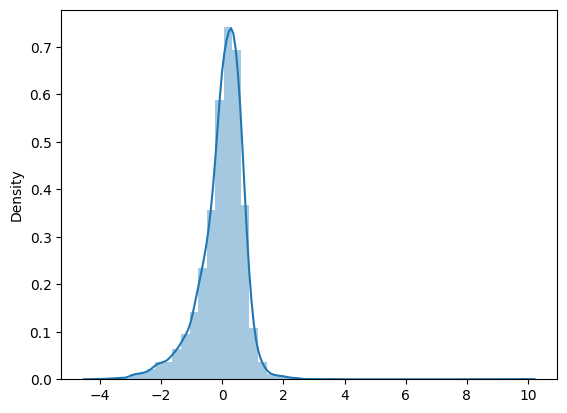

In [30]:
sns.distplot(ridge_pred-y_test)

In [31]:
score=r2_score(ridge_pred,y_test)
score

0.34383945441404484

# 3. Lasso Regression

In [32]:
from sklearn.linear_model import Lasso


In [33]:
lasso = Lasso()



# **Unsupervised Learning**

**1.K mean ckustering**

In [34]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
from sklearn.datasets import make_blobs

In [35]:
X,y = make_blobs(n_samples=1000,n_features=2,centers=3,cluster_std=1.8,random_state=23)

In [36]:
X.shape

(1000, 2)

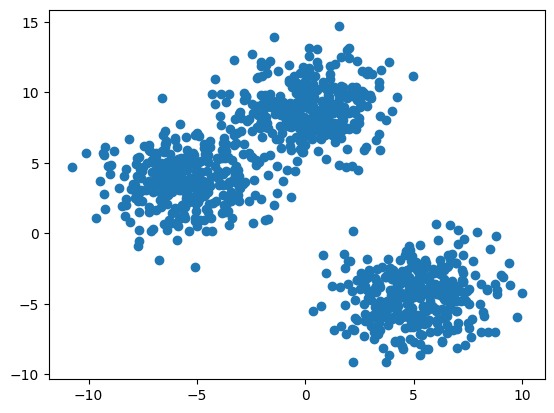

In [37]:
plt.scatter(X[:,0],X[:,1])

In [38]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.3,random_state=42)

In [39]:
from sklearn.cluster import KMeans

In [40]:
#Manual process
#Elbow Method to select the K value

wcss=[]
for k in range(1,11):
  kmeans=KMeans(n_clusters=k,init='k-means++')
  kmeans.fit(X_train)
  wcss.append(kmeans.inertia_)


In [41]:
wcss

[39299.30277180709,
 11222.178820592915,
 4443.153339704342,
 3843.8136333877214,
 3539.666537582421,
 3160.869821645164,
 2530.2816956690563,
 2216.2026701965365,
 1990.025434858604,
 1808.9263922476032]

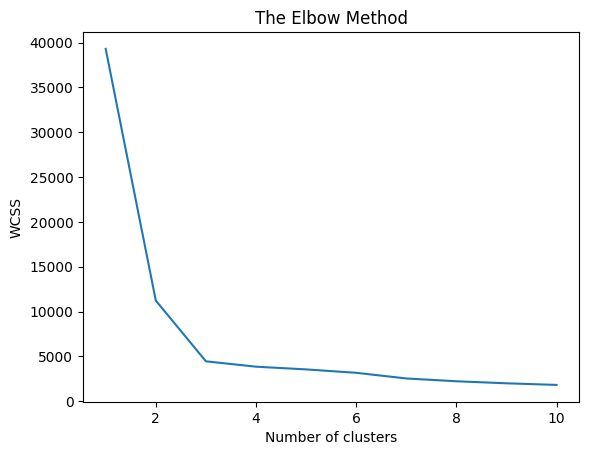

In [42]:
#plot elbow curve
plt.plot(range(1,11),wcss)
plt.title('The Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.show()


In [43]:
kmeans=KMeans(n_clusters=3,init='k-means++')
y_labels=kmeans.fit_predict(X_train)

In [44]:
y_test_label=kmeans.predict(X_test)

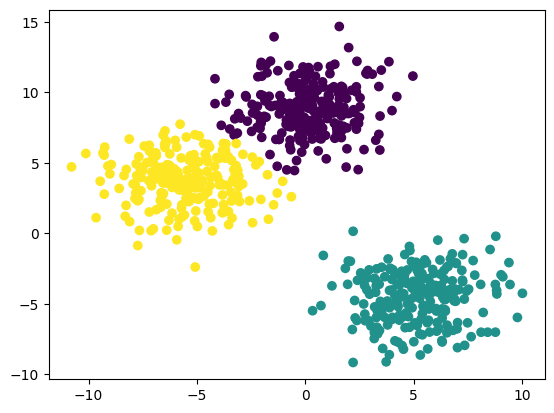

In [45]:
plt.scatter(X_train[:,0],X_train[:,1],c=y_labels)

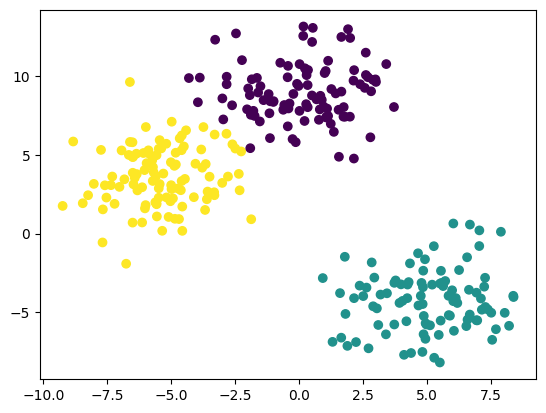

In [46]:
plt.scatter(X_test[:,0],X_test[:,1],c=y_test_label)

In [47]:
#knee locator
!pip install kneed

In [48]:
from kneed import KneeLocator

In [49]:
kl=knnelocator=KneeLocator(range(1,11),wcss,curve='convex',direction='decreasing')
kl.elbow

np.int64(3)

In [50]:
#performance metrics
#silhoitte score
from sklearn.metrics import silhouette_score

In [51]:
silhouette_coefficient=[]
for k in range(2,11):
  kmeans=KMeans(n_clusters=k,init='k-means++')
  kmeans.fit(X_train)
  score=silhouette_score(X_train,kmeans.labels_)
  silhouette_coefficient.append(score)

In [52]:
silhouette_coefficient

[np.float64(0.6556734655802409),
 np.float64(0.6512865120181226),
 np.float64(0.5504379087866426),
 np.float64(0.40444621380351936),
 np.float64(0.3346583369554373),
 np.float64(0.34901245071369674),
 np.float64(0.3446303869786691),
 np.float64(0.3403699162131556),
 np.float64(0.33575087417583155)]

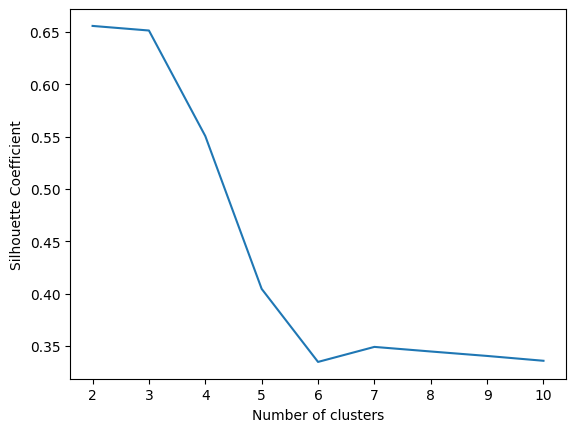

In [53]:
#plot silhouette score
plt.plot(range(2,11),silhouette_coefficient)
plt.xlabel('Number of clusters')
plt.ylabel('Silhouette Coefficient')
plt.show()

**2.Hierarichal clustering**

In [54]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
from sklearn import datasets

In [55]:
iris= datasets.load_iris()

In [56]:
iris_data=pd.DataFrame(iris.data,columns=iris.feature_names)

In [57]:
iris_data

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2
...,...,...,...,...
145,6.7,3.0,5.2,2.3
146,6.3,2.5,5.0,1.9
147,6.5,3.0,5.2,2.0
148,6.2,3.4,5.4,2.3


In [58]:
#standardization
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()

In [59]:
X_scaled = scaler.fit_transform(iris_data)

In [60]:
X_scaled

array([[-9.00681170e-01,  1.01900435e+00, -1.34022653e+00,
        -1.31544430e+00],
       [-1.14301691e+00, -1.31979479e-01, -1.34022653e+00,
        -1.31544430e+00],
       [-1.38535265e+00,  3.28414053e-01, -1.39706395e+00,
        -1.31544430e+00],
       [-1.50652052e+00,  9.82172869e-02, -1.28338910e+00,
        -1.31544430e+00],
       [-1.02184904e+00,  1.24920112e+00, -1.34022653e+00,
        -1.31544430e+00],
       [-5.37177559e-01,  1.93979142e+00, -1.16971425e+00,
        -1.05217993e+00],
       [-1.50652052e+00,  7.88807586e-01, -1.34022653e+00,
        -1.18381211e+00],
       [-1.02184904e+00,  7.88807586e-01, -1.28338910e+00,
        -1.31544430e+00],
       [-1.74885626e+00, -3.62176246e-01, -1.34022653e+00,
        -1.31544430e+00],
       [-1.14301691e+00,  9.82172869e-02, -1.28338910e+00,
        -1.44707648e+00],
       [-5.37177559e-01,  1.47939788e+00, -1.28338910e+00,
        -1.31544430e+00],
       [-1.26418478e+00,  7.88807586e-01, -1.22655167e+00,
      

In [61]:
X_scaled.shape

(150, 4)

In [62]:
#Apply the PCA
from sklearn.decomposition import PCA
pca=PCA(n_components=2)

In [63]:
pca_scaled=pca.fit_transform(X_scaled)

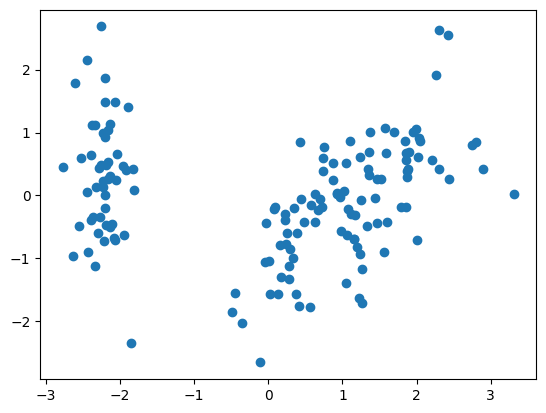

In [64]:
plt.scatter(pca_scaled[:,0],pca_scaled[:,1])

Text(0, 0.5, 'Euclidean Distance')

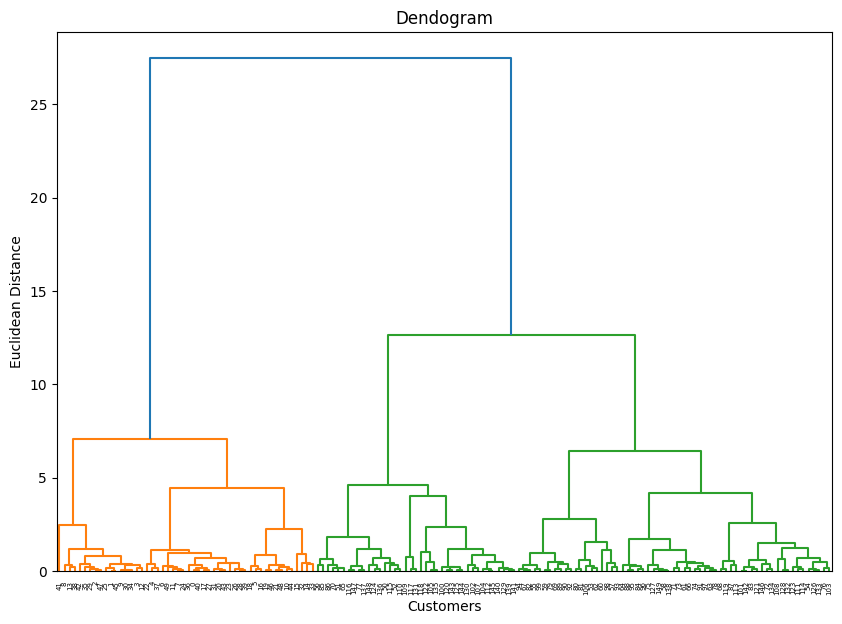

In [65]:
#Agglomerative Clustering
#to construct a dendogram
import scipy.cluster.hierarchy as sc
#plot the dendogram
plt.figure(figsize=(10,7))
plt.title('Dendrogram')
sc.dendrogram(sc.linkage(pca_scaled,method='ward'))
plt.title("Dendogram")
plt.xlabel('Customers')
plt.ylabel('Euclidean Distance')

In [66]:
from sklearn.cluster import AgglomerativeClustering
cluster=AgglomerativeClustering(n_clusters=2,metric='euclidean',linkage='ward')
cluster.fit(pca_scaled)

AgglomerativeClustering()

In [67]:
cluster.labels_

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

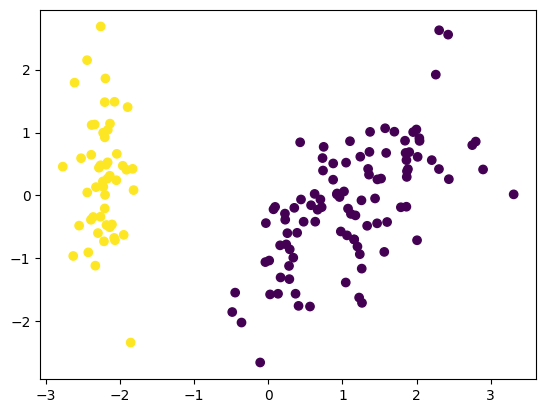

In [68]:
plt.scatter(pca_scaled[:,0],pca_scaled[:,1],c=cluster.labels_)

In [69]:
#silhouette score
from sklearn.metrics import silhouette_score
silhouette_score(pca_scaled,cluster.labels_)

np.float64(0.6145202036230452)

In [70]:
silhouette_coefficient=[]
for k in range(2,11):
  cluster=AgglomerativeClustering(n_clusters=k,metric='euclidean',linkage='ward')
  cluster.fit(pca_scaled)
  score=silhouette_score(pca_scaled,cluster.labels_)
  silhouette_coefficient.append(score)

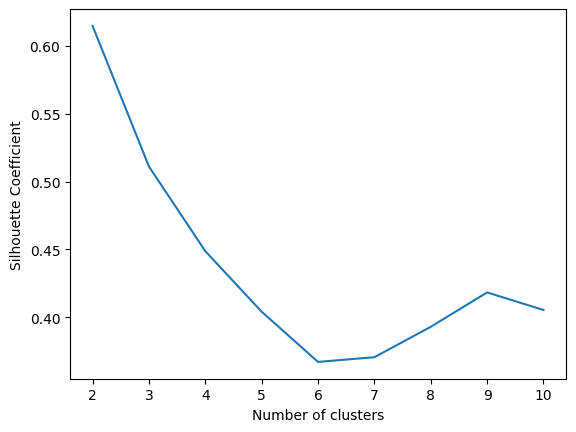

In [71]:
plt.plot(range(2,11),silhouette_coefficient)
plt.xlabel('Number of clusters')
plt.ylabel('Silhouette Coefficient')
plt.show()

**3.DBSCAN Clustering**

In [72]:
from sklearn.cluster import DBSCAN
from sklearn.datasets import make_moons
import matplotlib.pyplot as plt
%matplotlib inline


In [73]:
X,y= make_moons(n_samples=250,noise=.05)

In [74]:
X

array([[ 4.99090550e-01,  8.66619031e-01],
       [-9.23271041e-01,  2.70913088e-01],
       [ 4.37655291e-01, -3.09906200e-01],
       [ 4.49376434e-01, -3.34938522e-01],
       [ 1.21129288e+00, -4.86551645e-01],
       [ 1.39817944e+00, -3.39624523e-01],
       [ 3.92156258e-02,  8.62755076e-02],
       [ 1.92201114e+00,  2.69443155e-01],
       [ 1.33348212e-01, -9.27694860e-02],
       [ 6.96556396e-01,  6.70035158e-01],
       [ 6.90070805e-01,  7.95443760e-01],
       [ 1.30343377e+00, -5.21051346e-01],
       [ 2.45240066e-01,  9.75486152e-01],
       [-2.67421774e-01,  9.40794072e-01],
       [ 9.48009554e-01,  3.70469991e-01],
       [ 8.41557741e-01,  6.20334270e-01],
       [ 3.42145445e-01, -2.64164607e-01],
       [ 1.24510450e+00, -4.53443524e-01],
       [ 1.74288753e+00, -1.07668007e-01],
       [ 1.62120746e+00, -2.83643270e-01],
       [ 9.21359768e-01,  4.63653543e-01],
       [ 1.75028276e-01,  9.43696381e-01],
       [ 2.97920869e-01, -2.11055621e-01],
       [-1.

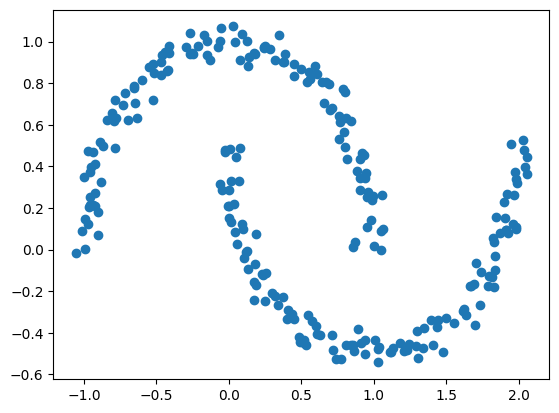

In [75]:
plt.scatter(X[:,0],X[:,1])

In [76]:
#feature scaling (standard scaling)
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [77]:
#DBSCAN algo.
dbscan=DBSCAN(eps=.5)




In [78]:
dbscan.fit(X_scaled)

DBSCAN()

In [79]:
dbscan.labels_

array([0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0,
       1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1,
       0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0, 1, 0, 0, 0,
       0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0,
       1, 1, 0, 1, 1, 1, 1, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1,
       1, 1, 1, 1, 0, 1, 0, 1, 0, 1, 1, 0, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0,
       1, 0, 1, 1, 0, 1, 0, 0, 0, 1, 0, 1, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0,
       1, 1, 1, 0, 0, 0, 0, 1, 1, 0, 1, 1, 0, 0, 0, 1, 1, 1, 1, 1, 1, 0,
       1, 1, 1, 1, 1, 0, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 1, 0, 1, 0,
       0, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0,
       0, 1, 0, 1, 1, 1, 0, 1, 0, 0, 1, 1, 1, 0, 1, 1, 1, 0, 0, 1, 0, 1,
       0, 0, 1, 0, 1, 0, 1, 0])

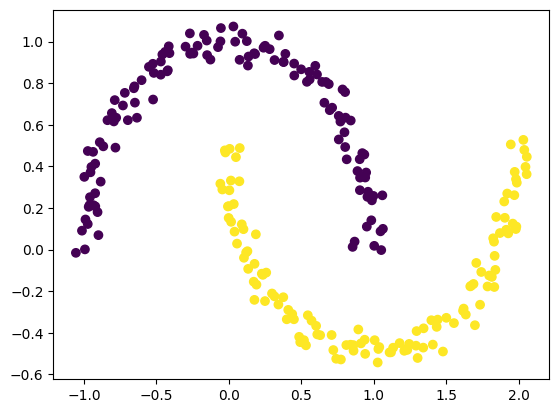

In [80]:
from sklearn.cluster import DBSCAN
# Re-initialize and fit DBSCAN to ensure labels_ attribute is available
dbscan = DBSCAN(eps=.5) # Ensure this matches the intended eps value
dbscan.fit(X_scaled) # Fit the model to the scaled data
plt.scatter(X[:,0],X[:,1],c=dbscan.labels_)

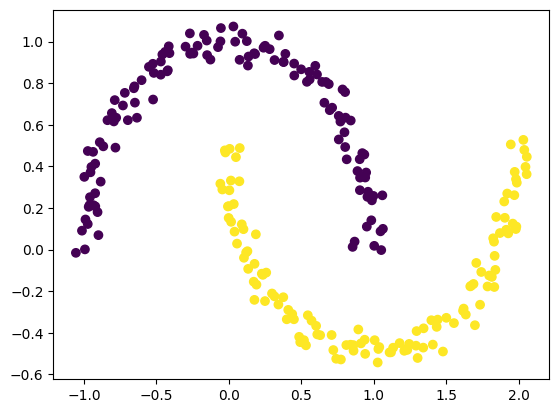

In [81]:
plt.scatter(X[:,0],X[:,1],c=y)

In [82]:
 #Example 2
from sklearn.cluster import DBSCAN
from sklearn.datasets import make_moons
import matplotlib.pyplot as plt
%matplotlib inline
from sklearn.datasets import make_circles

In [83]:
X,y= make_circles(n_samples=750,factor=.3,noise=.01)

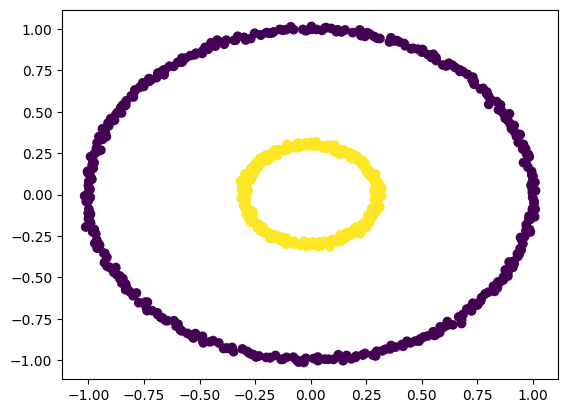

In [84]:
plt.scatter(X[:,0],X[:,1],c=y)

In [85]:
from sklearn.cluster import DBSCAN
# Re-initialize and fit DBSCAN to ensure labels_ attribute is available
dbscan = DBSCAN(eps=.1) # Ensure this matches the intended eps value


In [86]:
dbscan.fit_predict(X)

array([0, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 1, 0,
       0, 1, 0, 1, 0, 0, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 0, 0, 1,
       1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1,
       0, 0, 1, 1, 0, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0, 1, 1, 1, 1, 0, 0, 1,
       0, 1, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0,
       0, 0, 1, 0, 0, 1, 1, 0, 1, 1, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 1,
       1, 1, 1, 0, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0,
       1, 0, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0,
       1, 1, 0, 1, 0, 1, 1, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 0, 0,
       1, 1, 1, 0, 0, 0, 1, 0, 1, 1, 1, 1, 0, 0, 0, 1, 1, 0, 1, 0, 1, 1,
       0, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 1, 0,
       0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0,
       1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 0, 1, 1, 0, 0, 0,
       0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 0,

In [87]:

dbscan.labels_

array([0, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 1, 0,
       0, 1, 0, 1, 0, 0, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 0, 0, 1,
       1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1,
       0, 0, 1, 1, 0, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0, 1, 1, 1, 1, 0, 0, 1,
       0, 1, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0,
       0, 0, 1, 0, 0, 1, 1, 0, 1, 1, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 1,
       1, 1, 1, 0, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0,
       1, 0, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0,
       1, 1, 0, 1, 0, 1, 1, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 0, 0,
       1, 1, 1, 0, 0, 0, 1, 0, 1, 1, 1, 1, 0, 0, 0, 1, 1, 0, 1, 0, 1, 1,
       0, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 1, 0,
       0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0,
       1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 0, 1, 1, 0, 0, 0,
       0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 0,

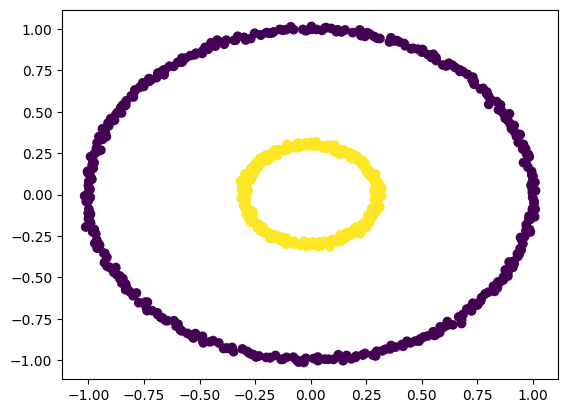

In [88]:
plt.scatter(X[:,0],X[:,1],c=dbscan.labels_)

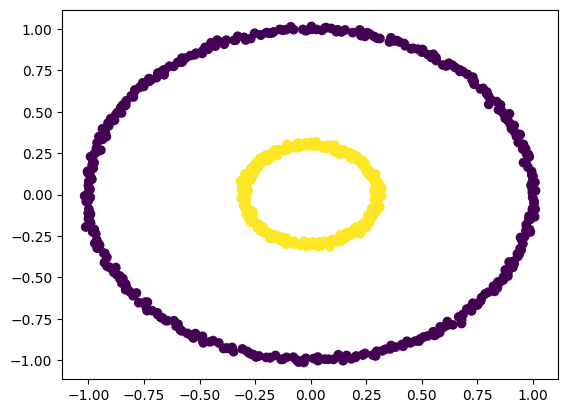

In [89]:
plt.scatter(X[:,0],X[:,1],c=y)

In [94]:
import joblib
from google.colab import drive
drive.mount('/content/drive')

joblib.dump(regression, '/content/drive/MyDrive/linear_regression_model.pkl')

Mounted at /content/drive


['/content/drive/MyDrive/linear_regression_model.pkl']